<a href="https://colab.research.google.com/github/sb0611sb/2026BDA/blob/main/seoul_fire_vulnerability_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 서울시 소방차 진입취약 지역 분석

OpenStreetMap 도로망 데이터를 활용해 **소방차가 진입하기 어려운 지역**을 분석하고,
그 결과를 실제 위성지도 위에 시각화합니다.

- 분석 대상: 서울특별시 25개 자치구
- 사용 라이브러리: `osmnx`, `geopandas`, `networkx`, `folium`, `contextily`

## 분석 개요

서울시는 '소방차 진입곤란 구간'을 정제된 공개 데이터로 제공하지 않습니다.
따라서 본 분석은 OpenStreetMap 도로망에서 취약 구간을 **직접 도출**합니다.

**두 가지 지표를 결합**해 자치구별 취약도를 산출합니다.

1. **좁은 도로 비율** — 도로 위계(OSM `highway` 태그)를 도로 폭의 대리지표로 사용해,
   `living_street`·`residential` 등 좁은 골목이 전체 도로에서 차지하는 비율을 계산
2. **소방서 접근성** — 도로망을 따라 각 소방서에서 5분(골든타임) 안에 도달 가능한
   범위를 계산하고, 도달하지 못하는 지역의 비율을 계산

**종합 취약 점수 = 좁은도로 비율(50%) + 소방서 미도달 비율(50%)**

분석 흐름: `데이터 수집 → 도로 분류 → 두 지표 계산 → 종합 점수 → 위성지도 시각화`

> ⚠️ 실행에는 인터넷 연결이 필요합니다(OSM 데이터 다운로드). 최초 실행 시 도로망
> 다운로드에 수 분이 걸릴 수 있으며, 캐시가 저장되어 재실행은 빨라집니다.

## 0. 라이브러리 준비

In [8]:
# 필요 라이브러리 설치 (최초 1회만 실행, 이미 설치돼 있으면 건너뛰어도 됩니다)
%pip install -q "osmnx>=2.0" geopandas folium networkx contextily matplotlib mapclassify shapely koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 49.6 MB/s eta 0:00:00


In [9]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import contextily as cx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
import koreanize_matplotlib
warnings.filterwarnings("ignore")

plt.rcParams["axes.unicode_minus"] = False

# OSM 다운로드 캐시 사용 → 재실행 시 빠름
ox.settings.use_cache = True
ox.settings.log_console = False

print("osmnx 버전:", ox.__version__)

osmnx 버전: 2.1.0


## 1. 행정구역 경계 수집

서울 25개 자치구의 경계를 OpenStreetMap geocoding으로 가져와
하나의 `GeoDataFrame`으로 모읍니다. 분석 결과를 자치구 단위로 집계할 때 사용합니다.

In [10]:
# 서울 25개 자치구 경계 수집
gu_en = ["Jongno","Jung","Yongsan","Seongdong","Gwangjin","Dongdaemun","Jungnang",
         "Seongbuk","Gangbuk","Dobong","Nowon","Eunpyeong","Seodaemun","Mapo",
         "Yangcheon","Gangseo","Guro","Geumcheon","Yeongdeungpo","Dongjak",
         "Gwanak","Seocho","Gangnam","Songpa","Gangdong"]
gu_kr = ["종로구","중구","용산구","성동구","광진구","동대문구","중랑구",
         "성북구","강북구","도봉구","노원구","은평구","서대문구","마포구",
         "양천구","강서구","구로구","금천구","영등포구","동작구",
         "관악구","서초구","강남구","송파구","강동구"]

rows = []
for en, kr in zip(gu_en, gu_kr):
    try:
        g = ox.geocode_to_gdf(f"{en}-gu, Seoul, South Korea")[["geometry"]].copy()
        g["gu_kr"], g["gu_en"] = kr, en
        rows.append(g)
        print(f"  OK   {kr}")
    except Exception as e:
        print(f"  실패 {kr}: {e}")

districts = gpd.GeoDataFrame(pd.concat(rows, ignore_index=True), crs="EPSG:4326")
print(f"\n수집 완료: {len(districts)}개 자치구")
districts.head()

  OK   종로구
  OK   중구
  OK   용산구
  OK   성동구
  OK   광진구
  OK   동대문구
  OK   중랑구
  OK   성북구
  OK   강북구
  OK   도봉구
  OK   노원구
  OK   은평구
  OK   서대문구
  OK   마포구
  OK   양천구
  OK   강서구
  OK   구로구
  OK   금천구
  OK   영등포구
  OK   동작구
  OK   관악구
  OK   서초구
  OK   강남구
  OK   송파구
  OK   강동구

수집 완료: 25개 자치구


,geometry,gu_kr,gu_en
0,"POLYGON ((126.9489 37.62526, 126.94901 37.6240...",종로구,Jongno
1,"POLYGON ((126.96154 37.55862, 126.96157 37.558...",중구,Jung
2,"POLYGON ((126.94458 37.53377, 126.94704 37.531...",용산구,Yongsan
3,"POLYGON ((127.0083 37.54515, 127.00834 37.5449...",성동구,Seongdong
4,"POLYGON ((127.0572 37.53012, 127.06287 37.5266...",광진구,Gwangjin


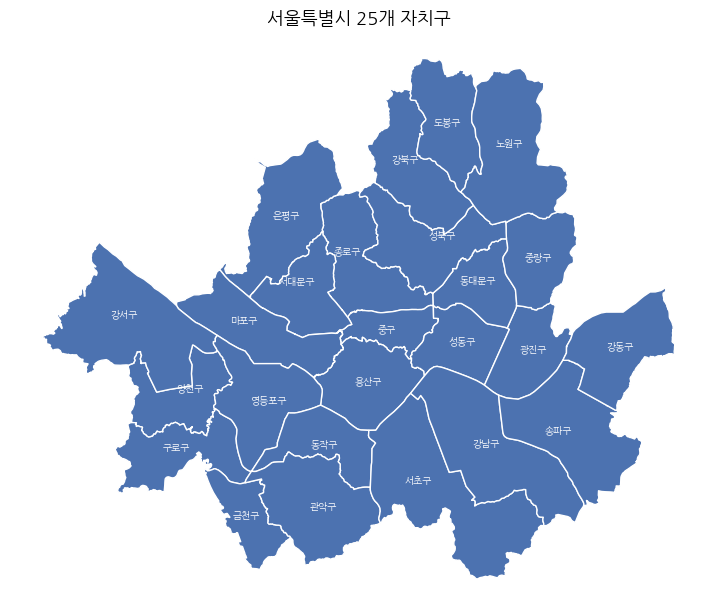

In [11]:
# 자치구 경계 미리보기
ax = districts.plot(figsize=(9, 9), edgecolor="white", facecolor="#4C72B0")
for _, r in districts.iterrows():
    c = r.geometry.representative_point()
    ax.annotate(r["gu_kr"], (c.x, c.y), ha="center", fontsize=7, color="white")
ax.set_title("서울특별시 25개 자치구", fontsize=13)
ax.axis("off")
plt.show()

## 2. 도로망 수집

서울 전역의 차량 통행 도로망을 내려받습니다. `network_type="drive"` 는 보행로·계단
등을 제외한 차량 통행 가능 도로만 가져옵니다.

> 이 셀은 다운로드량이 많아 **최초 실행 시 수 분**이 걸릴 수 있습니다.

In [12]:
# 서울 전체 도로망 수집 (차량 통행 도로)
G = ox.graph_from_place("Seoul, South Korea", network_type="drive", simplify=True)
print(f"노드 {G.number_of_nodes():,}개 / 도로구간 {G.number_of_edges():,}개")

노드 68,035개 / 도로구간 187,752개


In [13]:
# 그래프를 GeoDataFrame으로 변환 (도로구간 분석용)
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.reset_index()          # u, v, key 를 컬럼으로 펼침
print("도로 GeoDataFrame:", edges.shape)
edges[["highway", "length", "geometry"]].head()

도로 GeoDataFrame: (187752, 19)


,highway,length,geometry
0,residential,66.892380,"LINESTRING (126.99742 37.52596, 126.99813 37.5..."
1,tertiary,22.682960,"LINESTRING (126.99742 37.52596, 126.99717 37.5..."
2,tertiary,8.982724,"LINESTRING (126.99742 37.52596, 126.99752 37.5..."
3,residential,23.935361,"LINESTRING (127.02354 37.58805, 127.02329 37.5..."
4,residential,22.670334,"LINESTRING (127.02354 37.58805, 127.0235 37.58..."


## 3. 소방서 위치 수집

소방서와 119안전센터의 위치를 OSM `amenity=fire_station` 태그로 가져옵니다.
건물(폴리곤)로 표시된 경우 대표점으로 변환해 포인트로 통일합니다.

In [14]:
# 소방서 / 119안전센터 위치 수집
fire = ox.features_from_place("Seoul, South Korea", tags={"amenity": "fire_station"})
fire = fire[fire.geometry.notna()].copy()

# 폴리곤 → 대표점, 좌표계 통일(EPSG:4326)
fire_pts = gpd.GeoDataFrame(
    geometry=fire.to_crs(5179).representative_point(), crs="EPSG:5179"
).to_crs(4326)
print(f"소방 관서 {len(fire_pts)}개 수집")

소방 관서 87개 수집


## 4. 도로 분류 — 좁은 도로 식별

OSM에는 도로 폭(`width`) 정보가 일부 구간에만 입력돼 있어, **도로 위계(`highway` 태그)를
폭의 대리지표**로 사용합니다.

| 분류 | 해당 highway 태그 | 의미 |
|------|------------------|------|
| 좁은 도로 (narrow) | `living_street`, `residential`, `unclassified`, `road` | 소방차 진입곤란 가능 골목 |
| 통행가능 도로 (wide) | `tertiary` 이상 (간선·주요도로) | 소방차 통행 양호 |

`width` 태그가 입력된 구간은 실측 폭으로 보정합니다(3m 미만 → 좁음, 8m 이상 → 넓음).

In [15]:
# 도로 분류: 좁은 도로(narrow) vs 통행가능 도로(wide)
narrow_types = {"living_street", "residential", "unclassified", "road"}

def classify(hw):
    tags = set(hw) if isinstance(hw, list) else {hw}
    # 위계가 높은 도로가 하나라도 포함되면 '통행가능'으로 분류
    return "wide" if any(t not in narrow_types for t in tags) else "narrow"

edges["road_class"] = edges["highway"].apply(classify)

# (보정) width 태그가 있는 구간은 실측 폭 반영
def parse_width(w):
    if isinstance(w, list):
        w = w[0]
    try:
        return float(str(w).split()[0].replace("m", "").strip())
    except Exception:
        return np.nan

if "width" in edges.columns:
    edges["width_m"] = edges["width"].apply(parse_width)
    edges.loc[edges["width_m"] < 3.0, "road_class"] = "narrow"
    edges.loc[edges["width_m"] >= 8.0, "road_class"] = "wide"

vc = edges["road_class"].value_counts()
print(vc)
print(f"\n좁은 도로 비율(구간 수 기준): {vc.get('narrow', 0) / len(edges):.1%}")

road_class
narrow    148611
wide       39141
Name: count, dtype: int64

좁은 도로 비율(구간 수 기준): 79.2%


## 5. 분석 ① 자치구별 좁은 도로 비율

각 도로구간을 대표점 기준으로 자치구에 매칭한 뒤, 자치구별로
`좁은 도로 길이 ÷ 전체 도로 길이` 를 계산합니다. 비율이 높을수록 좁은 골목이 많은 지역입니다.

In [16]:
# 도로구간 → 자치구 공간 매칭
edges_pt = edges[["road_class", "length", "geometry"]].copy()
edges_pt["geometry"] = edges_pt.geometry.representative_point()

joined = gpd.sjoin(edges_pt, districts[["gu_kr", "geometry"]],
                   how="inner", predicate="within")

# 자치구 x 도로분류 별 길이 합계
agg = joined.groupby(["gu_kr", "road_class"])["length"].sum().unstack(fill_value=0)
for c in ["narrow", "wide"]:
    if c not in agg.columns:
        agg[c] = 0.0
agg["total_km"]     = (agg["narrow"] + agg["wide"]) / 1000
agg["narrow_ratio"] = agg["narrow"] / (agg["narrow"] + agg["wide"])
agg = agg.sort_values("narrow_ratio", ascending=False)
agg[["total_km", "narrow_ratio"]].round(3)

road_class,total_km,narrow_ratio
gu_kr,,
강북구,599.871,0.870
은평구,675.227,0.813
서대문구,555.710,0.805
도봉구,425.926,0.802
동대문구,595.343,0.771
성북구,744.698,0.769
광진구,511.066,0.764
관악구,471.425,0.742
중랑구,537.830,0.732


## 6. 분석 ② 소방서 접근성 (골든타임 등시 분석)

각 도로구간에 주행속도와 통행시간을 부여하고, **모든 소방서에서 동시에 출발**했을 때
5분(골든타임) 안에 도달 가능한 도로 노드를 계산합니다.
도달하지 못하는 노드가 많은 자치구일수록 소방 대응이 취약합니다.

In [17]:
# 도로구간에 주행속도·통행시간(초) 부여
try:
    G = ox.routing.add_edge_speeds(G)
    G = ox.routing.add_edge_travel_times(G)
except AttributeError:                      # 구버전 osmnx 호환
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

# 소방서를 도로망의 가장 가까운 노드에 매칭
fire_nodes = set(ox.distance.nearest_nodes(
    G, X=fire_pts.geometry.x.values, Y=fire_pts.geometry.y.values))
print(f"소방서가 매칭된 도로 노드: {len(fire_nodes)}개")

소방서가 매칭된 도로 노드: 84개


In [18]:
# 모든 소방서에서 5분 내 도달 가능한 노드 계산 (다중출발 최단경로)
GOLDEN_TIME = 300   # 초 (5분)

reach = nx.multi_source_dijkstra_path_length(
    G, sources=fire_nodes, cutoff=GOLDEN_TIME, weight="travel_time")
reachable = set(reach.keys())

print(f"5분 내 도달 가능 노드: {len(reachable):,} / 전체 {G.number_of_nodes():,}")
print(f"전체 미도달 비율: {1 - len(reachable) / G.number_of_nodes():.1%}")

5분 내 도달 가능 노드: 67,085 / 전체 68,035
전체 미도달 비율: 1.4%


In [19]:
# 자치구별 '5분 내 미도달' 노드 비율
nodes_j = gpd.sjoin(nodes[["geometry"]], districts[["gu_kr", "geometry"]],
                    how="inner", predicate="within")
nodes_j["covered"] = nodes_j.index.isin(reachable)

cov = nodes_j.groupby("gu_kr")["covered"].agg(n_total="count", n_covered="sum")
cov["uncovered_ratio"] = 1 - cov["n_covered"] / cov["n_total"]
cov.sort_values("uncovered_ratio", ascending=False)[["n_total", "uncovered_ratio"]].round(3)

,n_total,uncovered_ratio
gu_kr,,
노원구,2301,0.156
관악구,2156,0.067
금천구,1616,0.043
구로구,2537,0.032
서초구,3041,0.017
강동구,2976,0.017
송파구,3352,0.012
강서구,2646,0.009
동작구,1050,0.007


## 7. 종합 취약 점수

두 지표를 각각 0~1로 정규화(min-max)한 뒤 동일 가중치로 합산해
자치구별 **소방차 진입취약 점수**를 만듭니다.

`취약 점수 = 0.5 × 좁은도로 비율(정규화) + 0.5 × 소방서 미도달 비율(정규화)`

In [20]:
# 두 지표 결합 → 종합 취약 점수
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

result = (districts
          .merge(agg["narrow_ratio"].reset_index(), on="gu_kr")
          .merge(cov["uncovered_ratio"].reset_index(), on="gu_kr"))

result["score_narrow"] = minmax(result["narrow_ratio"])
result["score_access"] = minmax(result["uncovered_ratio"])
result["vuln_score"]   = 0.5 * result["score_narrow"] + 0.5 * result["score_access"]

result = result.round({"narrow_ratio": 3, "uncovered_ratio": 3,
                        "score_narrow": 3, "score_access": 3, "vuln_score": 3})
result.sort_values("vuln_score", ascending=False)[
    ["gu_kr", "narrow_ratio", "uncovered_ratio", "vuln_score"]].reset_index(drop=True)

,gu_kr,narrow_ratio,uncovered_ratio,vuln_score
0,노원구,0.620,0.156,0.558
1,강북구,0.870,0.003,0.511
2,관악구,0.742,0.067,0.489
3,은평구,0.813,0.006,0.420
4,서대문구,0.805,0.005,0.400
5,도봉구,0.802,0.000,0.379
6,구로구,0.725,0.032,0.348
7,성북구,0.769,0.002,0.328
8,동대문구,0.771,0.001,0.327
9,광진구,0.764,0.002,0.318


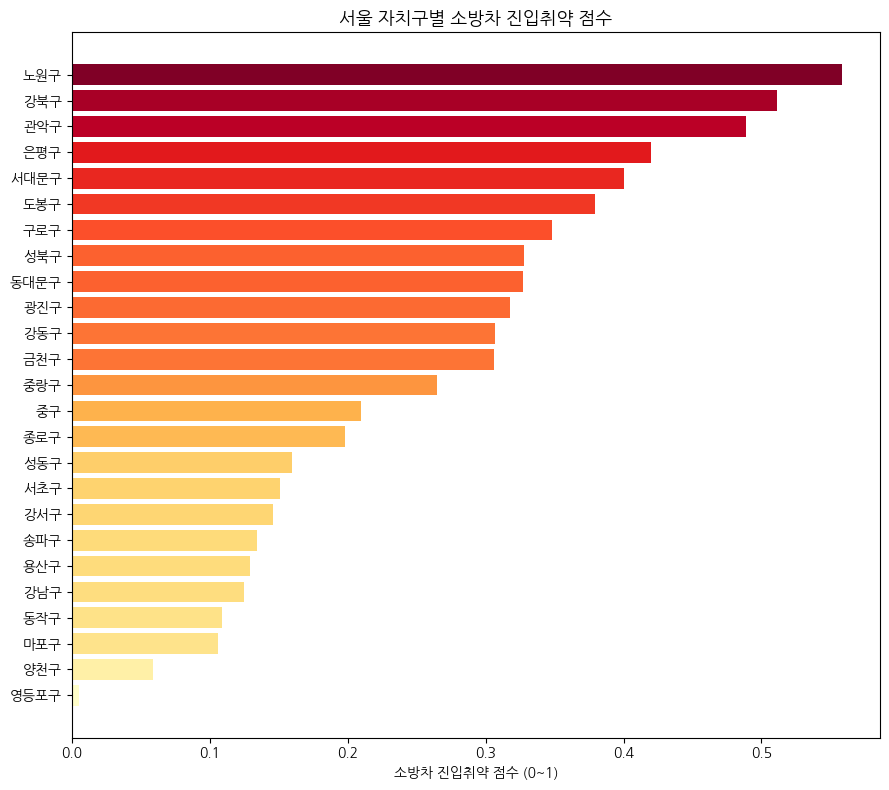

In [21]:
# 자치구별 취약 점수 막대그래프
plot_df = result.sort_values("vuln_score")
fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.YlOrRd(plot_df["vuln_score"] / plot_df["vuln_score"].max())
ax.barh(plot_df["gu_kr"], plot_df["vuln_score"], color=colors)
ax.set_xlabel("소방차 진입취약 점수 (0~1)")
ax.set_title("서울 자치구별 소방차 진입취약 점수", fontsize=13)
plt.tight_layout()
plt.show()

## 8. 위성지도 시각화

실제 위성지도(Esri World Imagery) 위에 두 가지 결과를 표시합니다.

1. **인터랙티브 지도** — 자치구별 취약 점수 단계구분도 + 소방서 위치
2. **정적 지도** — 좁은 도로(빨강)와 통행가능 도로(회색)의 분포

In [22]:
# (1) 위성지도 위 자치구별 취약 점수 — folium 인터랙티브 지도
SEOUL = [37.5665, 126.9780]
m = folium.Map(location=SEOUL, zoom_start=11, tiles=None)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery", name="위성지도").add_to(m)

folium.Choropleth(
    geo_data=result.to_json(), data=result,
    columns=["gu_kr", "vuln_score"], key_on="feature.properties.gu_kr",
    fill_color="YlOrRd", fill_opacity=0.55, line_color="white", line_opacity=0.8,
    legend_name="소방차 진입취약 점수").add_to(m)

folium.GeoJson(
    result, name="자치구 정보",
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["gu_kr", "vuln_score", "narrow_ratio", "uncovered_ratio"],
        aliases=["자치구", "취약점수", "좁은도로 비율", "5분 미도달 비율"])).add_to(m)

fg = folium.FeatureGroup(name="소방 관서")
for pt in fire_pts.geometry:
    folium.CircleMarker([pt.y, pt.x], radius=3, color="#00BFFF",
                        fill=True, fill_opacity=0.9).add_to(fg)
fg.add_to(m)

folium.LayerControl().add_to(m)
m.save("seoul_fire_vulnerability_map.html")
m

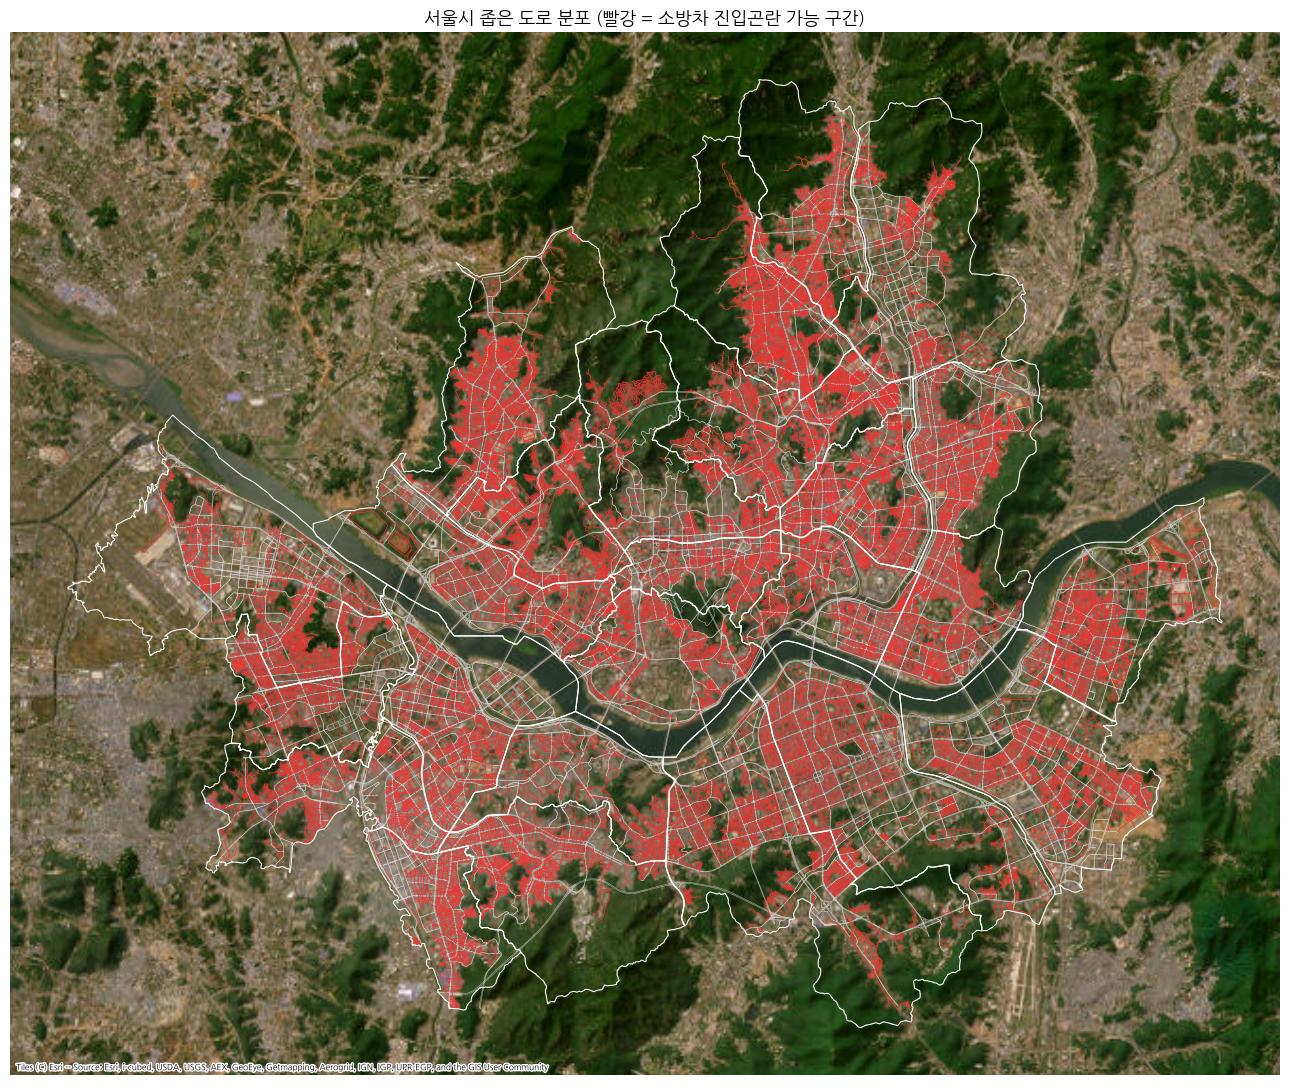

In [23]:
# (2) 좁은 도로 분포 — 위성 배경 위 정적 지도
edges_web = edges.to_crs(3857)
fig, ax = plt.subplots(figsize=(13, 13))
edges_web[edges_web.road_class == "wide"].plot(
    ax=ax, color="#dddddd", linewidth=0.4, alpha=0.7)
edges_web[edges_web.road_class == "narrow"].plot(
    ax=ax, color="#ff2d2d", linewidth=0.35, alpha=0.85)
districts.to_crs(3857).boundary.plot(ax=ax, color="white", linewidth=0.8)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, attribution_size=6)
ax.set_title("서울시 좁은 도로 분포 (빨강 = 소방차 진입곤란 가능 구간)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("seoul_narrow_roads.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. 결과 저장 및 요약

In [24]:
# 분석 결과 저장
result.drop(columns="geometry").to_csv(
    "seoul_fire_vulnerability.csv", index=False, encoding="utf-8-sig")

print("저장된 파일:")
print("  - seoul_fire_vulnerability.csv      (자치구별 분석 결과 표)")
print("  - seoul_fire_vulnerability_map.html (위성지도 인터랙티브)")
print("  - seoul_narrow_roads.png            (좁은 도로 분포 지도)")

top5 = result.sort_values("vuln_score", ascending=False).head(5)
print("\n[ 소방차 진입취약 상위 5개 자치구 ]")
for i, r in enumerate(top5.itertuples(), 1):
    print(f"  {i}. {r.gu_kr}  취약점수 {r.vuln_score}  "
          f"(좁은도로 {r.narrow_ratio}, 미도달 {r.uncovered_ratio})")

저장된 파일:
  - seoul_fire_vulnerability.csv      (자치구별 분석 결과 표)
  - seoul_fire_vulnerability_map.html (위성지도 인터랙티브)
  - seoul_narrow_roads.png            (좁은 도로 분포 지도)

[ 소방차 진입취약 상위 5개 자치구 ]
  1. 노원구  취약점수 0.558  (좁은도로 0.62, 미도달 0.156)
  2. 강북구  취약점수 0.511  (좁은도로 0.87, 미도달 0.003)
  3. 관악구  취약점수 0.489  (좁은도로 0.742, 미도달 0.067)
  4. 은평구  취약점수 0.42  (좁은도로 0.813, 미도달 0.006)
  5. 서대문구  취약점수 0.4  (좁은도로 0.805, 미도달 0.005)


### 분석의 한계와 보완 방향

- 도로 폭을 **실측이 아닌 도로 위계로 추정**했습니다. OSM `width` 태그가 입력된
  구간은 보정하지만, 전반적으로는 대리지표라는 점을 보고서에 명시하는 것이 좋습니다.
- 소방서 위치는 OSM 기반이라 일부 119안전센터가 누락될 수 있습니다.
  공공데이터포털의 소방서 좌표 데이터(CSV)로 대체하면 정확도가 올라갑니다.
- 통행속도는 osmnx 기본값이며, 실제 소방차 속도·교통 혼잡·불법주정차는 반영하지 않습니다.
- **보완 아이디어**: 건축물대장(노후 건물 밀도), 수치표고모델(경사도),
  불법주정차 단속 데이터를 추가 결합하면 취약도 추정을 더 정교화할 수 있습니다.